# Stellar Class — S6E6 | v4 (consolidato)

## Dove siamo arrivati (riepilogo)

- **La metrica è balanced accuracy**, non accuracy. Confermato: OOF balanced acc ≈ 0.9570 ≈ LB 0.9566. Da qui in poi guardiamo *solo* la balanced accuracy.
- **Feature set fissato**: fotometria `u,g,r,i,z` + indici di colore + `redshift` + 2 categoriche native (`spectral_type`, `galaxy_population`). `alpha`/`delta` restano: valgono ~1.3% (bias osservativo ereditato dal generatore sintetico, non rumore).
- **Errore principale = asse STAR↔GALAXY** (~10k oggetti): redshift sbavato dal generatore → in gran parte rumore di etichetta irrecuperabile. Non lo inseguiamo.
- **Leva disponibile ora**: la balanced accuracy pesa le 3 classi uguali, quindi la decisione argmax (ottima per accuracy) non è ottima per la nostra metrica. La allineiamo con la **prior-correction** (un solo parametro `t`).

## Struttura del notebook
1. Load + feature engineering
2. Categoriche native + target encoding
3. Training 5-fold (LightGBM)
4. Metriche OOF (accuracy **e** balanced accuracy)
5. Prior-correction: tuning di `t` sull'OOF
6. Submission con predizioni corrette
7. *(Appendice opzionale: diagnostica)*

## 1. Load + Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

import kagglehub
kagglehub.competition_download('playground-series-s6e6')
BASE = '/kaggle/input/competitions/playground-series-s6e6'
print('Setup ✓')

Setup ✓


In [2]:
train = pd.read_csv(f'{BASE}/train.csv')
test  = pd.read_csv(f'{BASE}/test.csv')

def build_features(df):
    """Indici di colore SDSS: differenze di magnitudine tra bande = pendenza spettrale."""
    df = df.copy()
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['u_r'] = df['u'] - df['r']
    df['u_z'] = df['u'] - df['z']
    df['g_z'] = df['g'] - df['z']
    return df

train = build_features(train)
test  = build_features(test)
print(f'Train: {train.shape} | Test: {test.shape}')

Train: (577347, 19) | Test: (247435, 18)


## 2. Categoriche native + target encoding
Categorie **condivise** train+test → codici interi coerenti (non è leakage: dichiariamo solo quali valori esistono).

In [3]:
cat_features = ['spectral_type', 'galaxy_population']
for col in cat_features:
    shared = sorted(set(train[col].astype(str)) | set(test[col].astype(str)))
    train[col] = pd.Categorical(train[col].astype(str), categories=shared)
    test[col]  = pd.Categorical(test[col].astype(str),  categories=shared)

TARGET   = 'class'
DROP     = ['id', TARGET]
FEATURES = [c for c in train.columns if c not in DROP]

le_target = LabelEncoder()
y = le_target.fit_transform(train[TARGET])
print(f'Target: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}')

X      = train[FEATURES]   # le category dtype vengono auto-rilevate da LightGBM
X_test = test[FEATURES]
print(f'Features ({len(FEATURES)}): {FEATURES}')

Target: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
Features (17): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'u_z', 'g_z']


## 3. Training 5-fold (LightGBM)
Params baseline solidi. Early stopping su multi_logloss (smooth); le metriche di interesse le calcoliamo dopo.

In [4]:
PARAMS = {
    'objective': 'multiclass', 'num_class': 3, 'metric': 'multi_logloss',
    'n_estimators': 3000, 'learning_rate': 0.05, 'num_leaves': 63,
    'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8,
    'subsample_freq': 1, 'colsample_bytree': 0.8, 'reg_alpha': 0.1,
    'reg_lambda': 1.0, 'n_jobs': -1, 'random_state': 42, 'verbose': -1,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds  = np.zeros((len(X), 3))
test_preds = np.zeros((len(X_test), 3))

for fold, (t_idx, v_idx) in enumerate(skf.split(X, y)):
    m = lgb.LGBMClassifier(**PARAMS)
    m.fit(X.iloc[t_idx], y[t_idx],
          eval_set=[(X.iloc[v_idx], y[v_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_preds[v_idx] = m.predict_proba(X.iloc[v_idx])
    test_preds      += m.predict_proba(X_test) / 5
    print(f'Fold {fold+1} | iter={m.best_iteration_}')

print('Training completato ✓')

Fold 1 | iter=652
Fold 2 | iter=629
Fold 3 | iter=610
Fold 4 | iter=643
Fold 5 | iter=675
Training completato ✓


## 4. Metriche OOF — guardiamo la metrica GIUSTA
`oof_classes` = argmax della posterior (decisione ottima per *accuracy*).

In [5]:
oof_classes = oof_preds.argmax(1)

print(f'OOF accuracy          : {accuracy_score(y, oof_classes):.5f}')
print(f'OOF balanced accuracy : {balanced_accuracy_score(y, oof_classes):.5f}   ← la metrica del LB')
print()
print(classification_report(y, oof_classes, target_names=le_target.classes_))

OOF accuracy          : 0.96827
OOF balanced accuracy : 0.95686   ← la metrica del LB

              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98    377480
         QSO       0.97      0.97      0.97    117143
        STAR       0.93      0.93      0.93     82724

    accuracy                           0.97    577347
   macro avg       0.96      0.96      0.96    577347
weighted avg       0.97      0.97      0.97    577347



## 5. Prior-correction — allineiamo la decisione alla balanced accuracy

La decisione Bayes-ottima per la balanced accuracy non è `argmax P(c|x)`, ma `argmax P(c|x)/P(c)`.
Usiamo **un solo** parametro `t` (temperatura sui prior):
- `t=0` → argmax normale (ottimo per accuracy)
- `t=1` → correzione Bayes piena (ottimo per balanced accuracy)
- intermedi → interpolano

Un solo parametro tunato su 577k righe ≈ zero rischio di overfitting.

t* = 1.000
OOF balanced acc | t=0  (argmax)        : 0.95686
OOF balanced acc | t=1  (Bayes pieno)   : 0.96559
OOF balanced acc | t=t* (1.00)           : 0.96559


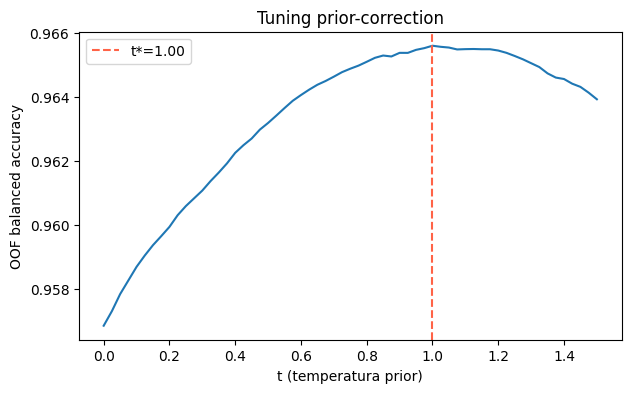

In [6]:
priors = np.bincount(y) / len(y)

ts  = np.linspace(0, 1.5, 61)
bas = [balanced_accuracy_score(y, (oof_preds / priors**t).argmax(1)) for t in ts]
t_best = ts[int(np.argmax(bas))]

print(f't* = {t_best:.3f}')
print(f'OOF balanced acc | t=0  (argmax)        : {bas[0]:.5f}')
print(f'OOF balanced acc | t=1  (Bayes pieno)   : {balanced_accuracy_score(y, (oof_preds/priors).argmax(1)):.5f}')
print(f'OOF balanced acc | t=t* ({t_best:.2f})           : {max(bas):.5f}')

plt.figure(figsize=(7,4))
plt.plot(ts, bas)
plt.axvline(t_best, color='tomato', ls='--', label=f't*={t_best:.2f}')
plt.xlabel('t (temperatura prior)'); plt.ylabel('OOF balanced accuracy')
plt.legend(); plt.title('Tuning prior-correction'); plt.show()

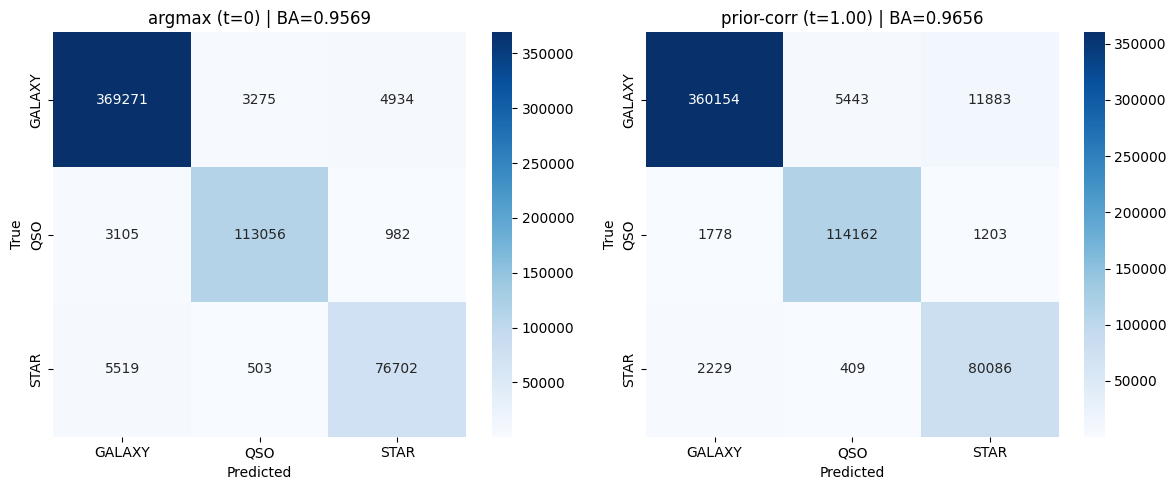

Recall per classe DOPO la correzione:
              precision    recall  f1-score   support

      GALAXY       0.99      0.95      0.97    377480
         QSO       0.95      0.97      0.96    117143
        STAR       0.86      0.97      0.91     82724

    accuracy                           0.96    577347
   macro avg       0.93      0.97      0.95    577347
weighted avg       0.96      0.96      0.96    577347



In [7]:
# Confusion matrix: prima (t=0) vs dopo (t=t*) — per vedere COSA cambia
oof_corr = (oof_preds / priors**t_best).argmax(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, ttl in [(axes[0], oof_classes, f'argmax (t=0) | BA={bas[0]:.4f}'),
                      (axes[1], oof_corr,    f'prior-corr (t={t_best:.2f}) | BA={max(bas):.4f}')]:
    cm = confusion_matrix(y, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le_target.classes_, yticklabels=le_target.classes_)
    ax.set_title(ttl); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

print('Recall per classe DOPO la correzione:')
print(classification_report(y, oof_corr, target_names=le_target.classes_))

## 6. Submission (predizioni prior-corrette)
**Stesso `t`** applicato al test.

In [8]:
test_classes = (test_preds / priors**t_best).argmax(1)
submission = pd.DataFrame({'id': test['id'],
                           'class': le_target.inverse_transform(test_classes)})
submission.to_csv('/kaggle/working/submission.csv', index=False)

print('submission.csv ✓')
print(submission['class'].value_counts())


submission.csv ✓
class
GALAXY    156181
QSO        51400
STAR       39854
Name: count, dtype: int64


---
## 7. Appendice (opzionale) — diagnostica
Le celle che ci hanno fatto *capire* il problema. Non servono per la submission, ma tienile come riferimento.

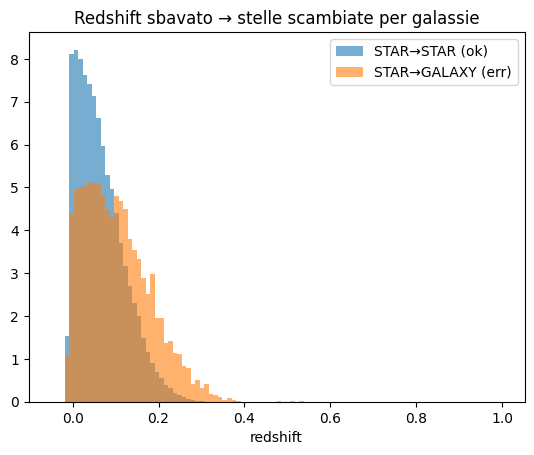

redshift mediano ok : 0.05446089840717825
redshift mediano err: 0.0932276436825469


In [9]:
# A) Errori STAR: dove finiscono? (conferma asse STAR↔GALAXY)
star_c   = list(le_target.classes_).index('STAR')
galaxy_c = list(le_target.classes_).index('GALAXY')
rs = train['redshift'].values

ok  = (y == star_c) & (oof_classes == star_c)
err = (y == star_c) & (oof_classes == galaxy_c)

plt.hist(rs[ok],  bins=100, range=(-0.05, 1), alpha=0.6, density=True, label='STAR→STAR (ok)')
plt.hist(rs[err], bins=100, range=(-0.05, 1), alpha=0.6, density=True, label='STAR→GALAXY (err)')
plt.xlabel('redshift'); plt.legend()
plt.title('Redshift sbavato → stelle scambiate per galassie'); plt.show()
print('redshift mediano ok :', np.median(rs[ok]))
print('redshift mediano err:', np.median(rs[err]))

In [10]:
# B) Adversarial validation: train e test hanno la stessa distribuzione? (AUC≈0.5 = sì)
from sklearn.metrics import roc_auc_score

X_adv = pd.concat([X, X_test], axis=0, ignore_index=True)
y_adv = np.concatenate([np.zeros(len(X)), np.ones(len(X_test))])
oof_adv = np.zeros(len(X_adv))

for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(X_adv, y_adv):
    a = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=63,
                           n_jobs=-1, random_state=42, verbose=-1)
    a.fit(X_adv.iloc[tr], y_adv[tr])
    oof_adv[va] = a.predict_proba(X_adv.iloc[va])[:, 1]

print('Adversarial AUC:', roc_auc_score(y_adv, oof_adv), '(≈0.5 → nessun drift)')

Adversarial AUC: 0.5005041749708314 (≈0.5 → nessun drift)
